<a href="https://colab.research.google.com/github/richayanamandra/GenAI-Experiments/blob/main/genAI_lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import random

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


In [2]:
IMG_SIZE    = 32
BATCH_SIZE  = 128
NUM_EPOCHS  = 60
LR          = 2e-4
BETA1       = 0.5
BETA2       = 0.999
L1_WEIGHT   = 10.0
MSE_WEIGHT  = 1.0
NOISE_STD   = 0.05
NUM_WORKERS = 2

print(f'Batch Size : {BATCH_SIZE}')
print(f'Epochs     : {NUM_EPOCHS}')
print(f'LR         : {LR}')
print(f'L1 Weight  : {L1_WEIGHT}')
print(f'MSE Weight : {MSE_WEIGHT}')
print(f'Input Noise: {NOISE_STD}')

Batch Size : 128
Epochs     : 60
LR         : 0.0002
L1 Weight  : 10.0
MSE Weight : 1.0
Input Noise: 0.05


In [3]:
class PairedCIFAR10(Dataset):
    """
    Input  (A): Grayscale + Noise  → simulates degraded image
    Target (B): Original color image
    Both normalized to [-1, 1]
    """
    def __init__(self, root, train=True, noise_std=0.05):
        self.noise_std = noise_std
        base_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # → [-1, 1]
        ])
        self.dataset = torchvision.datasets.CIFAR10(
            root=root, train=train, download=True, transform=base_transform
        )
        self.gray_weights = torch.tensor([0.299, 0.587, 0.114]).view(3, 1, 1)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        color_img, label = self.dataset[idx]           # (3,32,32), range [-1,1]
        gray = (color_img * self.gray_weights).sum(dim=0, keepdim=True)  # (1,32,32)
        gray_3ch = gray.repeat(3, 1, 1)                # (3,32,32)
        noisy_input = gray_3ch + torch.randn_like(gray_3ch) * self.noise_std
        noisy_input = noisy_input.clamp(-1.0, 1.0)
        return noisy_input, color_img, label

# Load
train_dataset = PairedCIFAR10('./data', train=True,  noise_std=NOISE_STD)
test_dataset  = PairedCIFAR10('./data', train=False, noise_std=NOISE_STD)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train samples: {len(train_dataset)}')
print(f'Test  samples: {len(test_dataset)}')

100%|██████████| 170M/170M [00:03<00:00, 43.5MB/s]


Train samples: 50000
Test  samples: 10000


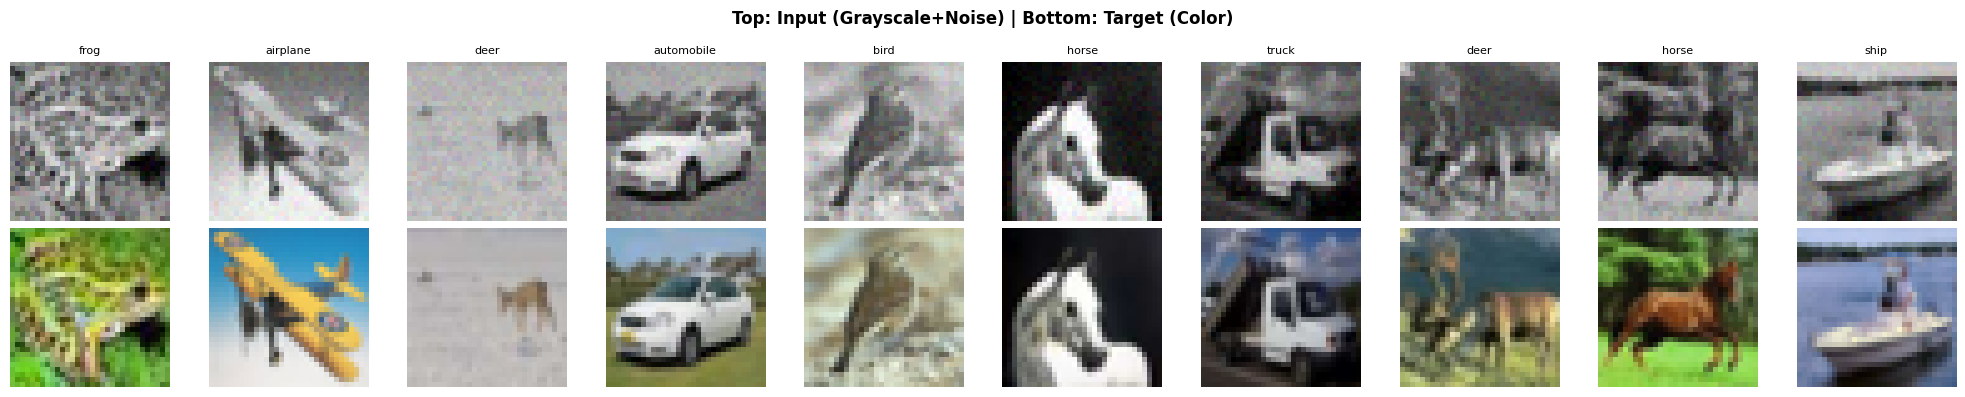

In [4]:
CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer',
                   'dog','frog','horse','ship','truck']

def denormalize(tensor):
    return (tensor * 0.5 + 0.5).clamp(0, 1)

inputs, targets, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 10, figsize=(20, 4))
fig.suptitle('Top: Input (Grayscale+Noise) | Bottom: Target (Color)', fontsize=12, fontweight='bold')

for i in range(10):
    axes[0, i].imshow(denormalize(inputs[i]).permute(1,2,0).numpy())
    axes[0, i].axis('off')
    axes[0, i].set_title(CIFAR10_CLASSES[labels[i].item()], fontsize=8)
    axes[1, i].imshow(denormalize(targets[i]).permute(1,2,0).numpy())
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [5]:
class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch, use_bn=True):
        super().__init__()
        layers = [nn.Conv2d(in_ch, out_ch, 4, stride=2, padding=1, bias=not use_bn)]
        if use_bn:
            layers.append(nn.BatchNorm2d(out_ch))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch, use_dropout=False):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_ch, out_ch, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        ]
        if use_dropout:
            layers.append(nn.Dropout(0.5))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class UNetEncoderDecoder(nn.Module):
    """
    Encoder: 32→16→8→4  |  Bottleneck: 4→2  |  Decoder: 2→4→8→16→32
    Skip connections at each level for detail preservation.
    """
    def __init__(self, in_channels=3, out_channels=3, base_features=64):
        super().__init__()
        bf = base_features

        # Encoder
        self.enc1 = EncoderBlock(in_channels, bf,   use_bn=False)  # 32→16
        self.enc2 = EncoderBlock(bf,          bf*2)                # 16→8
        self.enc3 = EncoderBlock(bf*2,        bf*4)                # 8→4

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(bf*4, bf*8, 4, stride=2, padding=1, bias=False),  # 4→2
            nn.LeakyReLU(0.2, inplace=True)
        )

        # Decoder (skip connections double input channels)
        self.dec1 = DecoderBlock(bf*8,   bf*4, use_dropout=True)   # 2→4
        self.dec2 = DecoderBlock(bf*4*2, bf*2, use_dropout=True)   # 4→8  (skip e3)
        self.dec3 = DecoderBlock(bf*2*2, bf,   use_dropout=False)  # 8→16 (skip e2)

        # Output
        self.output_conv = nn.Sequential(
            nn.ConvTranspose2d(bf*2, out_channels, 4, stride=2, padding=1),  # 16→32
            nn.Tanh()
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.normal_(m.weight, 0.0, 0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.normal_(m.weight, 1.0, 0.02)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        e1 = self.enc1(x)          # (B, 64,  16, 16)
        e2 = self.enc2(e1)         # (B, 128,  8,  8)
        e3 = self.enc3(e2)         # (B, 256,  4,  4)
        bn = self.bottleneck(e3)   # (B, 512,  2,  2)

        d1 = self.dec1(bn)                      # (B, 256, 4,  4)
        d2 = self.dec2(torch.cat([d1, e3], 1))  # (B, 128, 8,  8)
        d3 = self.dec3(torch.cat([d2, e2], 1))  # (B,  64, 16, 16)
        return self.output_conv(torch.cat([d3, e1], 1))  # (B, 3, 32, 32)


model = UNetEncoderDecoder().to(device)
total = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total:,}')
print(model)

Total parameters: 6,171,331
UNetEncoderDecoder(
  (enc1): EncoderBlock(
    (block): Sequential(
      (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): LeakyReLU(negative_slope=0.2, inplace=True)
    )
  )
  (enc2): EncoderBlock(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
    )
  )
  (enc3): EncoderBlock(
    (block): Sequential(
      (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
    )
  )
  (bottleneck): Sequential(
    (0): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)

In [7]:
criterion_mse = nn.MSELoss().to(device)
criterion_l1  = nn.L1Loss().to(device)

def combined_loss(pred, target):
    mse = criterion_mse(pred, target)
    l1  = criterion_l1(pred, target)
    total = MSE_WEIGHT * mse + L1_WEIGHT * l1
    return total, mse, l1

optimizer = optim.Adam(model.parameters(), lr=LR, betas=(BETA1, BETA2))

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
)

print('Loss     : MSE + 10 x L1')
print('Optimizer: Adam')
print('Scheduler: ReduceLROnPlateau')

Loss     : MSE + 10 x L1
Optimizer: Adam
Scheduler: ReduceLROnPlateau


In [8]:
train_losses, val_losses, mse_losses, l1_losses = [], [], [], []
best_val_loss = float('inf')
best_model_state = None

print(f'Training for {NUM_EPOCHS} epochs on {device}...\n')

for epoch in range(1, NUM_EPOCHS + 1):
    # ── Train ──
    model.train()
    ep_train, ep_mse, ep_l1 = 0.0, 0.0, 0.0

    for inp, tgt, _ in train_loader:
        inp, tgt = inp.to(device), tgt.to(device)
        out = model(inp)
        loss, mse, l1 = combined_loss(out, tgt)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        ep_train += loss.item()
        ep_mse   += mse.item()
        ep_l1    += l1.item()

    avg_train = ep_train / len(train_loader)
    avg_mse   = ep_mse   / len(train_loader)
    avg_l1    = ep_l1    / len(train_loader)

    # ── Validate ──
    model.eval()
    ep_val = 0.0
    with torch.no_grad():
        for inp, tgt, _ in test_loader:
            inp, tgt = inp.to(device), tgt.to(device)
            out = model(inp)
            loss, _, _ = combined_loss(out, tgt)
            ep_val += loss.item()

    avg_val = ep_val / len(test_loader)

    train_losses.append(avg_train)
    val_losses.append(avg_val)
    mse_losses.append(avg_mse)
    l1_losses.append(avg_l1)

    scheduler.step(avg_val)

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 5 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'Epoch [{epoch:3d}/{NUM_EPOCHS}] Train: {avg_train:.4f} | '
              f'Val: {avg_val:.4f} | MSE: {avg_mse:.4f} | L1: {avg_l1:.4f} | LR: {lr_now:.6f}')

model.load_state_dict(best_model_state)
print(f'\nTraining complete! Best Val Loss: {best_val_loss:.4f}')

Training for 60 epochs on cuda...

Epoch [  1/60] Train: 1.3089 | Val: 1.0806 | MSE: 0.0349 | L1: 0.1274 | LR: 0.000200
Epoch [  5/60] Train: 0.9961 | Val: 0.9898 | MSE: 0.0220 | L1: 0.0974 | LR: 0.000200
Epoch [ 10/60] Train: 0.9108 | Val: 0.9924 | MSE: 0.0189 | L1: 0.0892 | LR: 0.000200
Epoch [ 15/60] Train: 0.7982 | Val: 0.9925 | MSE: 0.0147 | L1: 0.0784 | LR: 0.000100
Epoch [ 20/60] Train: 0.7329 | Val: 0.9966 | MSE: 0.0125 | L1: 0.0720 | LR: 0.000050
Epoch [ 25/60] Train: 0.7047 | Val: 1.0047 | MSE: 0.0115 | L1: 0.0693 | LR: 0.000025
Epoch [ 30/60] Train: 0.6848 | Val: 1.0032 | MSE: 0.0109 | L1: 0.0674 | LR: 0.000025
Epoch [ 35/60] Train: 0.6735 | Val: 1.0042 | MSE: 0.0106 | L1: 0.0663 | LR: 0.000013
Epoch [ 40/60] Train: 0.6677 | Val: 1.0066 | MSE: 0.0104 | L1: 0.0657 | LR: 0.000006
Epoch [ 45/60] Train: 0.6645 | Val: 1.0079 | MSE: 0.0103 | L1: 0.0654 | LR: 0.000003
Epoch [ 50/60] Train: 0.6627 | Val: 1.0065 | MSE: 0.0102 | L1: 0.0652 | LR: 0.000002
Epoch [ 55/60] Train: 0.6619 |

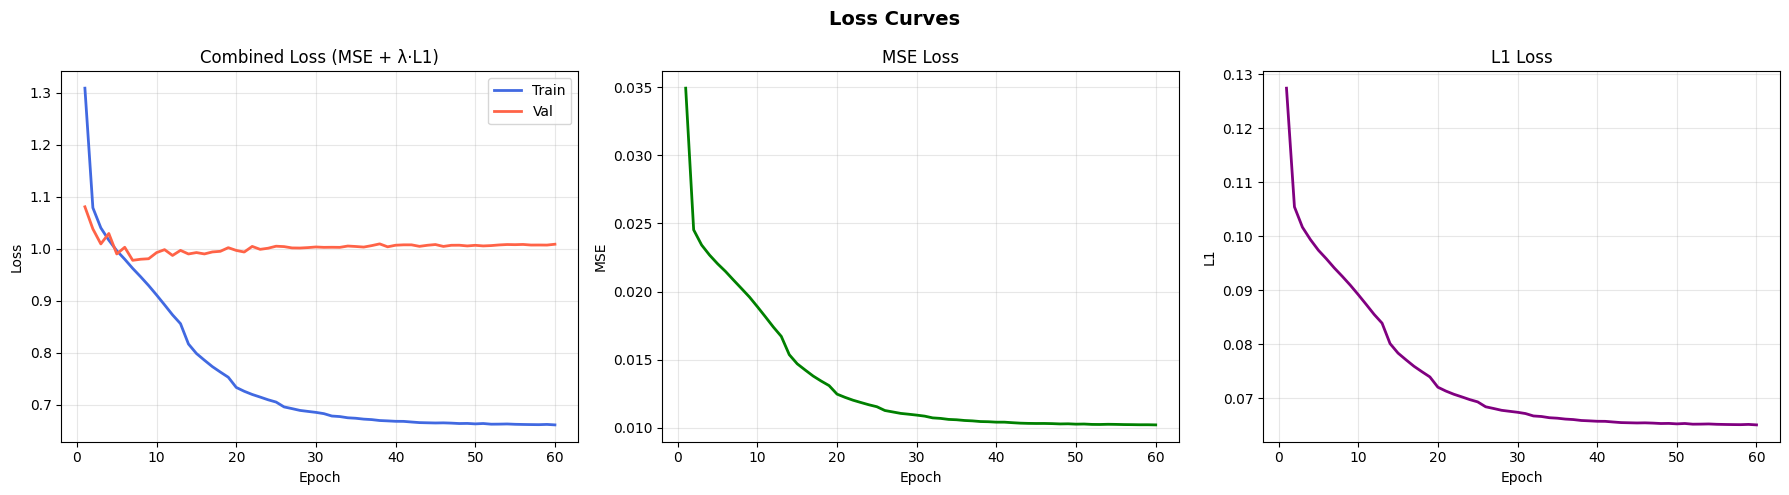

In [9]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Loss Curves', fontsize=14, fontweight='bold')

axes[0].plot(epochs_range, train_losses, label='Train', color='royalblue', linewidth=2)
axes[0].plot(epochs_range, val_losses,   label='Val',   color='tomato',    linewidth=2)
axes[0].set_title('Combined Loss (MSE + λ·L1)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, mse_losses, color='green', linewidth=2)
axes[1].set_title('MSE Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE')
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, l1_losses, color='purple', linewidth=2)
axes[2].set_title('L1 Loss')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('L1')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

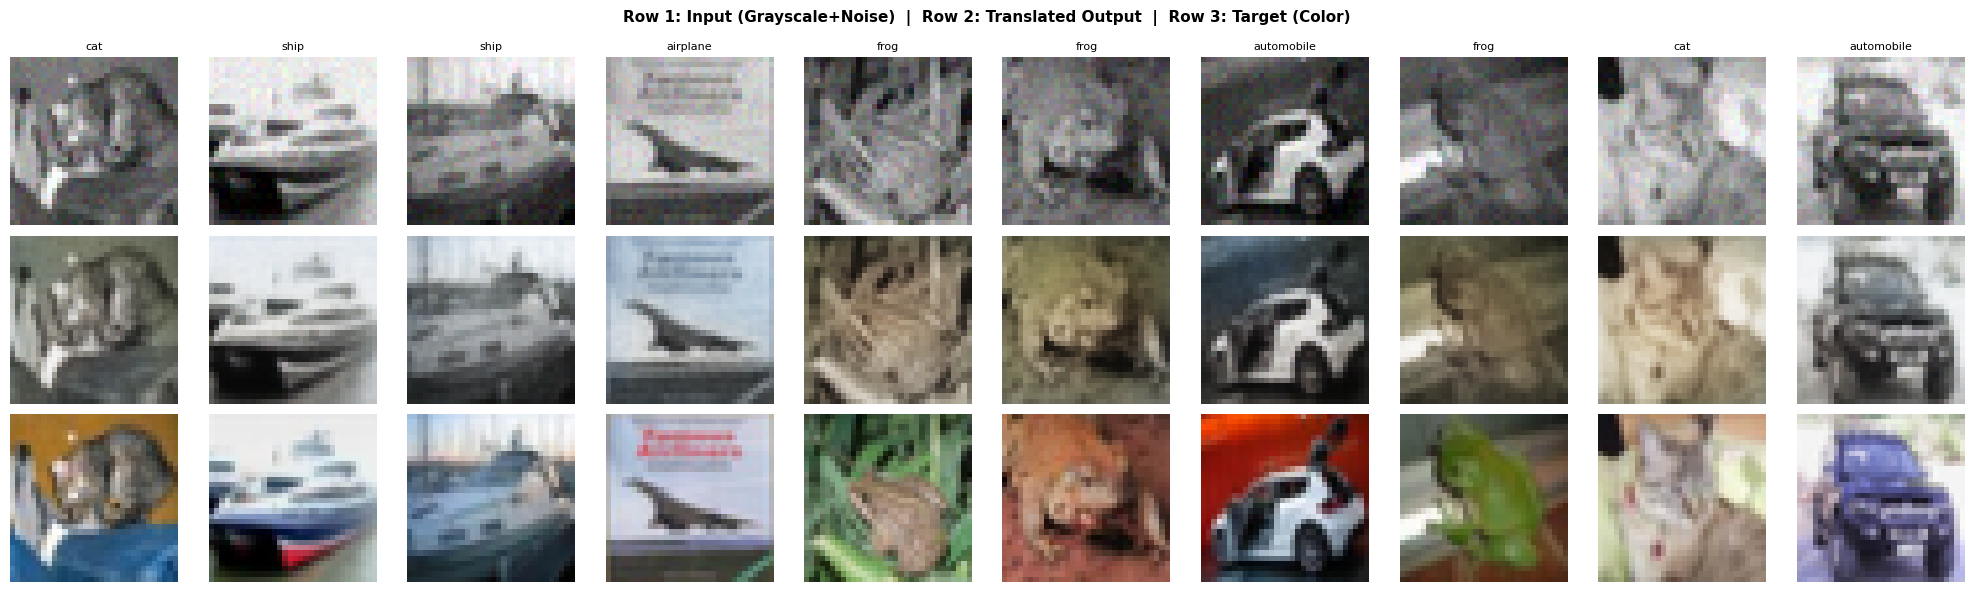

In [10]:
model.eval()
test_inputs, test_targets, test_labels = next(iter(test_loader))

with torch.no_grad():
    test_outputs = model(test_inputs.to(device)).cpu()

n = 10
fig, axes = plt.subplots(3, n, figsize=(20, 6))
fig.suptitle('Row 1: Input (Grayscale+Noise)  |  Row 2: Translated Output  |  Row 3: Target (Color)',
             fontsize=11, fontweight='bold')

for i in range(n):
    for row, data in enumerate([test_inputs, test_outputs, test_targets]):
        img = np.clip(denormalize(data[i]).permute(1,2,0).numpy(), 0, 1)
        axes[row, i].imshow(img)
        axes[row, i].axis('off')
    axes[0, i].set_title(CIFAR10_CLASSES[test_labels[i].item()], fontsize=8)

plt.tight_layout()
plt.show()

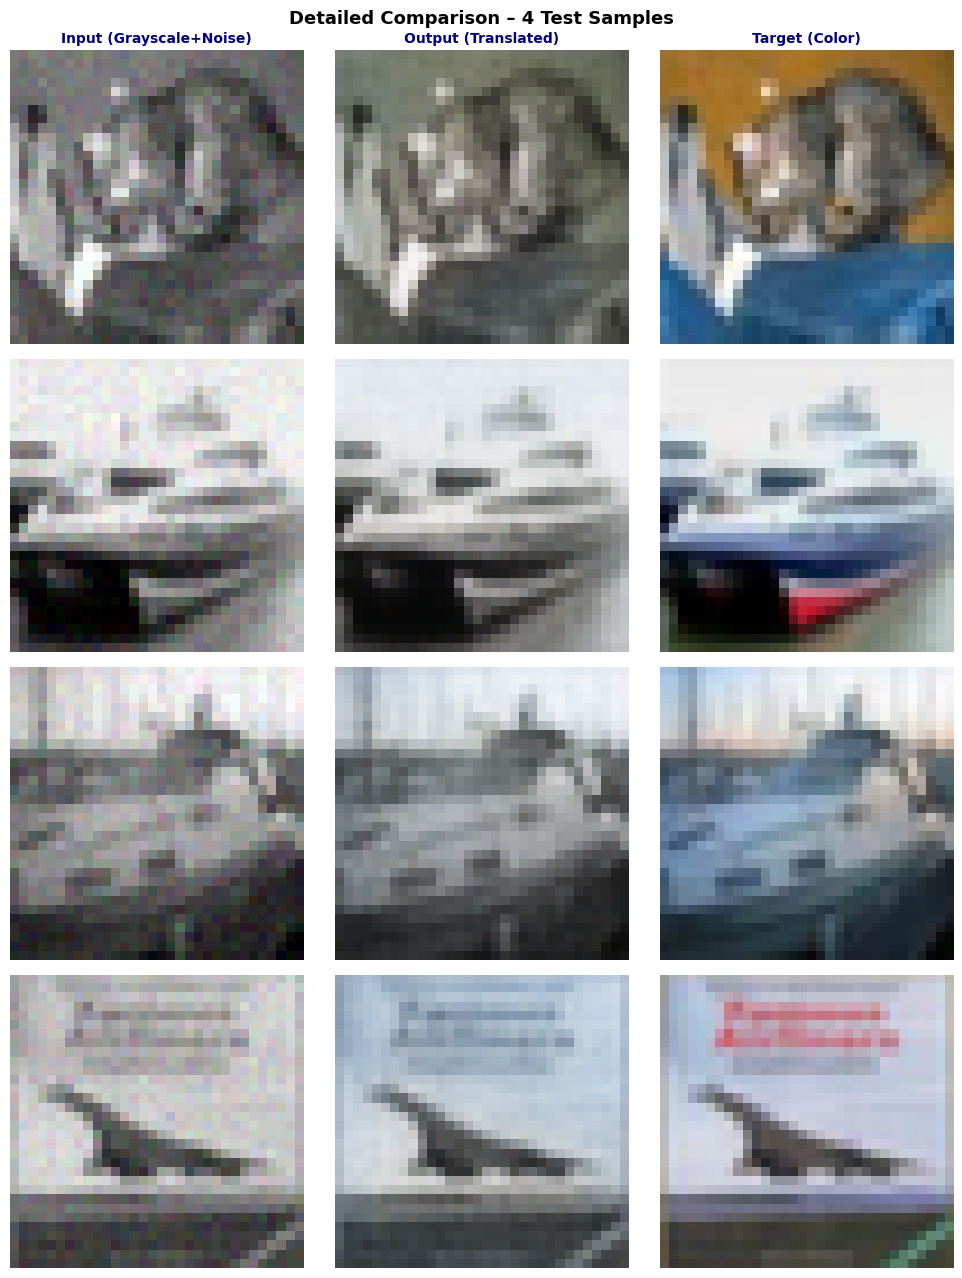

In [11]:
fig, axes = plt.subplots(4, 3, figsize=(10, 13))
fig.suptitle('Detailed Comparison – 4 Test Samples', fontsize=13, fontweight='bold')

for col, title in enumerate(['Input (Grayscale+Noise)', 'Output (Translated)', 'Target (Color)']):
    axes[0, col].set_title(title, fontsize=10, fontweight='bold', color='navy')

for i in range(4):
    imgs = [test_inputs[i], test_outputs[i], test_targets[i]]
    for j, img_t in enumerate(imgs):
        axes[i, j].imshow(np.clip(denormalize(img_t).permute(1,2,0).numpy(), 0, 1))
        axes[i, j].axis('off')

    mse_val = ((test_outputs[i] - test_targets[i])**2).mean().item()
    axes[i, 0].set_ylabel(f'Sample {i+1}\n[{CIFAR10_CLASSES[test_labels[i].item()]}]',
                           fontsize=9, rotation=0, labelpad=65, va='center')
    axes[i, 1].set_xlabel(f'MSE = {mse_val:.4f}', fontsize=8, color='green')

plt.tight_layout()
plt.show()

   QUANTITATIVE EVALUATION (Test Set)
  Overall MSE  : 0.02191
  Overall L1   : 0.09565
  PSNR         : 22.61 dB

  Per-Class MSE:
    airplane    : 0.03100
    automobile  : 0.02539
    bird        : 0.02463
    cat         : 0.01892
    deer        : 0.02091
    dog         : 0.02001
    frog        : 0.02024
    horse       : 0.01746
    ship        : 0.01868
    truck       : 0.02185


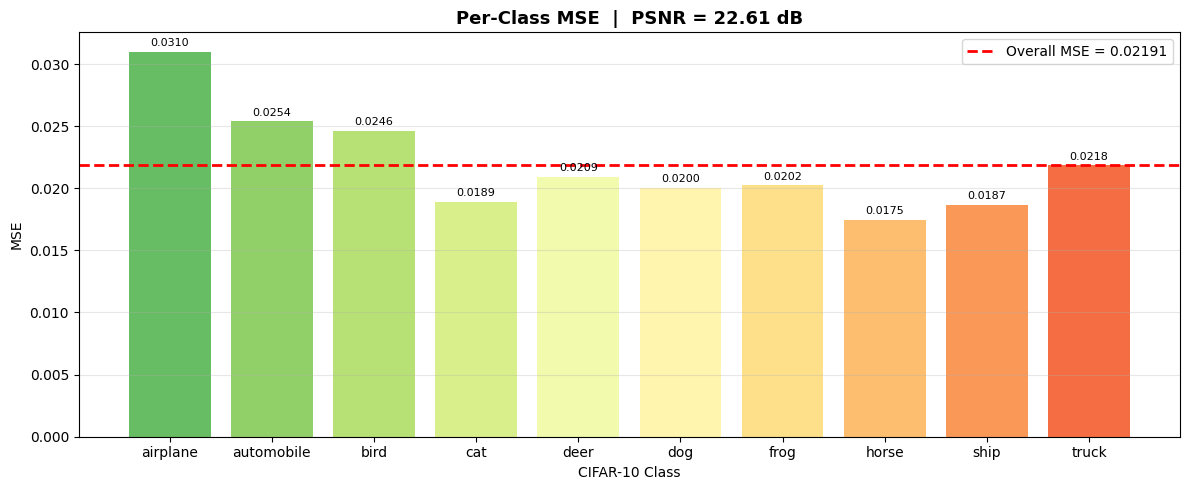

In [12]:
model.eval()
all_mse, all_l1 = [], []
class_mse = {c: [] for c in CIFAR10_CLASSES}

with torch.no_grad():
    for inp, tgt, lbl in test_loader:
        inp, tgt = inp.to(device), tgt.to(device)
        out = model(inp)
        for i in range(inp.size(0)):
            mse_v = ((out[i] - tgt[i])**2).mean().item()
            l1_v  = (out[i] - tgt[i]).abs().mean().item()
            all_mse.append(mse_v)
            all_l1.append(l1_v)
            class_mse[CIFAR10_CLASSES[lbl[i].item()]].append(mse_v)

overall_mse  = np.mean(all_mse)
overall_l1   = np.mean(all_l1)
overall_psnr = 10 * np.log10(4.0 / overall_mse)

print('=' * 45)
print('   QUANTITATIVE EVALUATION (Test Set)')
print('=' * 45)
print(f'  Overall MSE  : {overall_mse:.5f}')
print(f'  Overall L1   : {overall_l1:.5f}')
print(f'  PSNR         : {overall_psnr:.2f} dB')
print('\n  Per-Class MSE:')
for cls, vals in class_mse.items():
    print(f'    {cls:<12}: {np.mean(vals):.5f}')

# Bar chart
fig, ax = plt.subplots(figsize=(12, 5))
means = [np.mean(class_mse[c]) for c in CIFAR10_CLASSES]
bars  = ax.bar(CIFAR10_CLASSES, means, color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, 10)))
ax.axhline(overall_mse, color='red', linestyle='--', linewidth=2,
           label=f'Overall MSE = {overall_mse:.5f}')
ax.set_title(f'Per-Class MSE  |  PSNR = {overall_psnr:.2f} dB', fontsize=13, fontweight='bold')
ax.set_xlabel('CIFAR-10 Class'); ax.set_ylabel('MSE')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()